# Assignment Machine Learning

Student name: Vanessa Weiss

Student ID: 73217

Date: 08 March 2026

## 1. Data Preparation and extensions importing

### 1.1 Load extensions

In [1]:
# Import libaries
import pandas as pd
import numpy as np
import json
import seaborn as sns
import missingno as msno
import matplotlib.pylab as plt
import matplotlib.ticker as mticker

# Preprocessing & Pipelines
from feature_engineering import feature_engineering
from scipy.stats import chi2_contingency
from functools import partial
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.utils import compute_sample_weight
from sklearn.base import clone

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, precision_recall_curve

# Serialization
import pickle

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1.2 Load dataset, drop duplicates, drop all NaN rows

In [2]:
# Load data
df = pd.read_csv("complaints_training.csv")

# Remove duplicate rows
df = df.drop_duplicates()

# Drop rows where all values are NaN
df = df.dropna(how='all')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (321430, 18)

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Data types:
Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                o

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


### 1.3 Column name standardization

In [3]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df = df.rename(columns={
    'timely_response?': 'timely_response',
    'consumer_disputed?': 'consumer_disputed',
    'consumer_consent_provided?': 'consumer_consent_provided',
    'sub-issue': 'sub_issue',
    'sub-product': 'sub_product'
})

print("\nColumn names:")
print(df.columns.tolist())


Column names:
['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']


### 1.4 Column transformations

In [4]:
# Convert Timely response column to binary (Yes=1, No=0)
df['timely_response'] = df['timely_response'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Convert Consumer disputed column to binary (Yes=1, No=0)
# Map target variable and drop rows where target is NaN (e.g. 'N/A' values)
# 'N/A' means the dispute option was unavailable, not 'Not Disputed'
df['consumer_disputed'] = df['consumer_disputed'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['consumer_disputed'])
df['consumer_disputed'] = df['consumer_disputed'].astype(int)

# Convert date columns to datetime format
df['date_received'] = pd.to_datetime(df['date_received'], format='%Y-%m-%d')
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'], format='%Y-%m-%d')

# Derive year_month for temporal analysis
df['year_month'] = df['date_received'].dt.to_period('M')

# Derive channel type (Digital vs Non-Digital)
digital_channels = ['Web', 'Email']
df['channel_type'] = df['submitted_via'].apply(
    lambda x: 'Digital' if x in digital_channels else 'Non-Digital'
)

# Validate cleaned data
print("Shape of dataset after cleaning:", df.shape)

print("\nMissing values per column after cleaning:")
display(df.isna().sum().sort_values(ascending=False).head(15))

Shape of dataset after cleaning: (321430, 20)

Missing values per column after cleaning:


tags                            272731
consumer_complaint_narrative    266691
company_public_response         259597
consumer_consent_provided       221797
sub_issue                       170355
sub_product                      98075
state                             2145
zip_code                          1363
issue                                0
product                              0
date_received                        0
company                              0
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
dtype: int64

### 1.5 Handling missing values

date_received                        0
product                              0
sub_product                          0
issue                                0
sub_issue                            0
consumer_complaint_narrative    266691
company_public_response         259597
company                              0
state                                0
zip_code                             0
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response                      0
consumer_disputed                    0
complaint_id                         0
year_month                           0
channel_type                         0
dtype: int64


<Axes: >

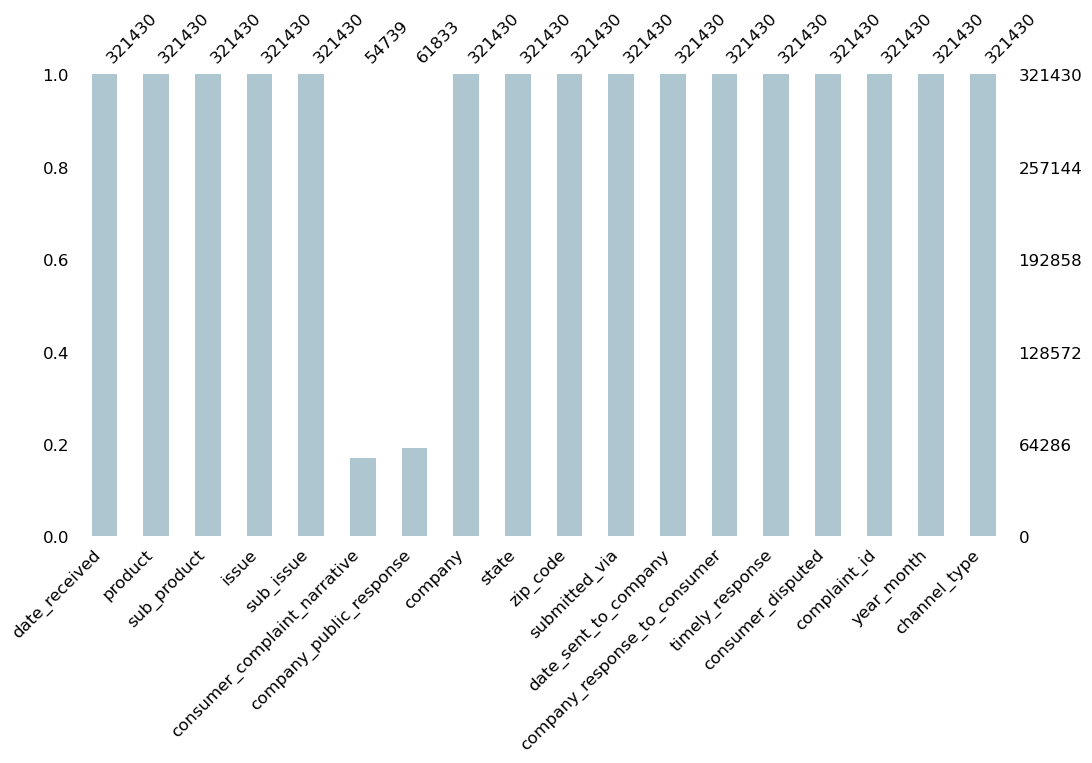

In [5]:
# Drop columns which do not contain meaningful information
df = df.drop(columns=['tags', 'consumer_consent_provided'])

# Fill with placeholder to preserve meaningful information of missing values
df['sub_issue'] = df['sub_issue'].fillna('unknown')
df['sub_product'] = df['sub_product'].fillna('unknown')
df['state'] = df['state'].fillna('unknown')
df['zip_code'] = df['zip_code'].fillna('unknown')

# Visualize missing data patterns after cleaning
missing_values = df.isna().sum()
print(missing_values)
msno.bar(df,color='#AEC6CF',figsize=(12,6), fontsize = 12)

### 1.6 Set numercial and categorical variables

In [6]:
#Inputing numerical and categorical variables
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_vars = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Convert categorical columns to type 'category'
df[categorical_vars] = df[categorical_vars].astype("category")

print(f"Those are the numerical columns: {numerical_vars}")
print(f"Those are the categorial columns: {categorical_vars}")

Those are the numerical columns: ['timely_response', 'consumer_disputed', 'complaint_id']
Those are the categorial columns: ['product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'submitted_via', 'company_response_to_consumer', 'channel_type']


### 1.7 Check target variable distribution

In [7]:
# Keep only rows where dispute status is known (Yes=1, No=0)
df = df[df['consumer_disputed'].isin([1, 0])].copy()
df['consumer_disputed'] = (df['consumer_disputed'] == 1).astype(int)

print(f"\nRows with known dispute status: {len(df):,} "
      f"({len(df)/len(df)*100:.1f}% of total)")
print(df['consumer_disputed'].value_counts(normalize=True).mul(100).round(2))


Rows with known dispute status: 321,430 (100.0% of total)
consumer_disputed
0    80.09
1    19.91
Name: proportion, dtype: float64


## Question 1

In the folloiwng the main drivers of complaint escalation (dispute) are analzyed. Whether a complaint resulted in a dispute or not is a binary outcome, so we compute dispute rates across categories and use visualizations and Chi-Square test to validate whether the observed differences are statistically significant. We investigate the following executive assumptions:

1. Assumption: Certain products generate more negative outcomes
2. Assumption: Digital channels escalate more frequently
3. Assumption: Regional differences influence response practices

In [8]:
# Helper: dispute rate + count per group
def dispute_rate(df, col, top_n=None):
    grp = (df.groupby(col, observed=True)['consumer_disputed']
               .agg(['sum', 'count'])
               .rename(columns={'sum': 'consumer_disputed', 'count': 'total'}))
    grp['rate'] = grp['consumer_disputed'] / grp['total'] * 100
    grp = grp.sort_values('rate', ascending=False)
    if top_n:
        grp = grp.head(top_n)
    return grp

# Helper: Chi-Square test
def chi2_test(df, col):
    ct = pd.crosstab(df[col], df['consumer_disputed'])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  Chi-Square = {chi2:.2f}, df = {dof}, p-value = {p:.4e}")
    return p

### Q1.1 - Assumption 1: Certain products generate more negative outcomes

                         consumer_disputed  total       rate
product                                                     
Virtual currency                         5      8  62.500000
Mortgage                             20170  85296  23.647064
Consumer Loan                         3017  13336  22.622975
Credit card                           6664  31274  21.308435
Bank account or service               6266  31802  19.703163
Student loan                          1708   8783  19.446658
Other financial service                 80    428  18.691589
Debt collection                      14543  78794  18.456989
Credit reporting                     10355  63510  16.304519
Payday loan                            522   3291  15.861440
Money transfers                        387   2788  13.880918
Prepaid card                           277   2120  13.066038

Statistical test (Chi-Square):
  Chi-Square = 1640.26, df = 11, p-value = 0.0000e+00


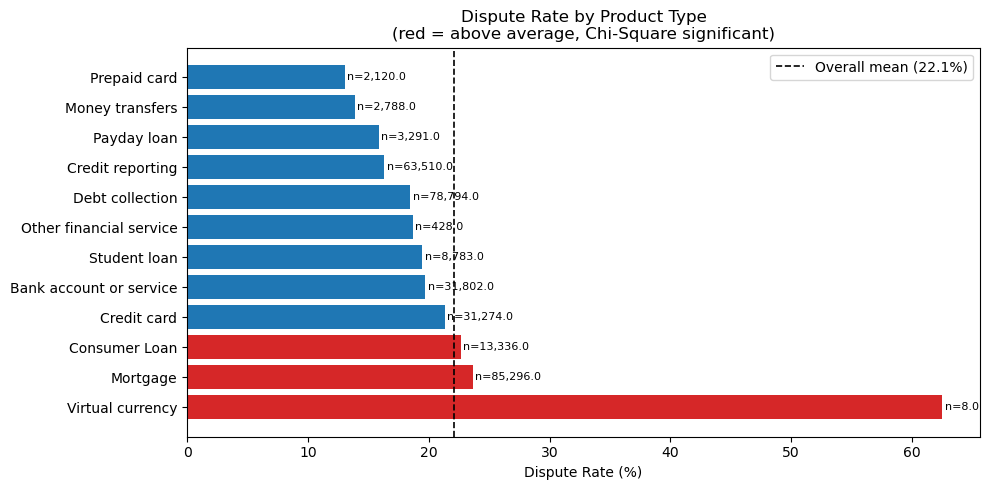

In [9]:
prod_stats = dispute_rate(df, 'product')
print(prod_stats.to_string())

print("\nStatistical test (Chi-Square):")
chi2_test(df, 'product')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if r > prod_stats['rate'].mean() else '#1f77b4'
          for r in prod_stats['rate']]
ax.barh(prod_stats.index, prod_stats['rate'], color=colors)
ax.axvline(prod_stats['rate'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Overall mean ({prod_stats['rate'].mean():.1f}%)")
ax.set_xlabel("Dispute Rate (%)")
ax.set_title("Dispute Rate by Product Type\n"
             "(red = above average, Chi-Square significant)")
ax.legend()

# Annotate with counts
for i, (idx, row) in enumerate(prod_stats.iterrows()):
    ax.text(row['rate'] + 0.2, i, f"n={row['total']:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation Assumption 1:**

The chi-squared test confirms that Assumption 1 is supported. Product categories will have significantly different dispute rates (Chi-Square p < 0.001). Mortage and consumer loan products show the highest dispute rates (~22–24%), while money transfers and prepaird cards tend to be lower (~13–15%). This wide spread confirms the assumption that product types drive the dispute outcome. Virtual currency has the highest dispute rate with 62.5%. This is most likely due to a very small sample size (only 8 total cases). Mortgage and Consumer Loan having high rates despite large samples and therefore represent a more robust and actionable finding.

### Q1.1 - Assumption 2: Digital channels escalate more frequently

Per channel:
                consumer_disputed   total       rate
submitted_via                                      
Email                         10      25  40.000000
Web                        49785  230522  21.596637
Fax                          945    4460  21.188341
Referral                    7297   45158  16.158820
Phone                       2978   20522  14.511256
Postal mail                 2979   20743  14.361471

Digital vs Non-Digital:
               consumer_disputed   total       rate
channel_type                                      
Digital                   49795  230547  21.598633
Non-Digital               14199   90883  15.623384

Statistical test (submitted_via):
  Chi-Square = 1596.28, df = 5, p-value = 0.0000e+00
Statistical test (Digital vs Non-Digital):
  Chi-Square = 1459.22, df = 1, p-value = 0.0000e+00


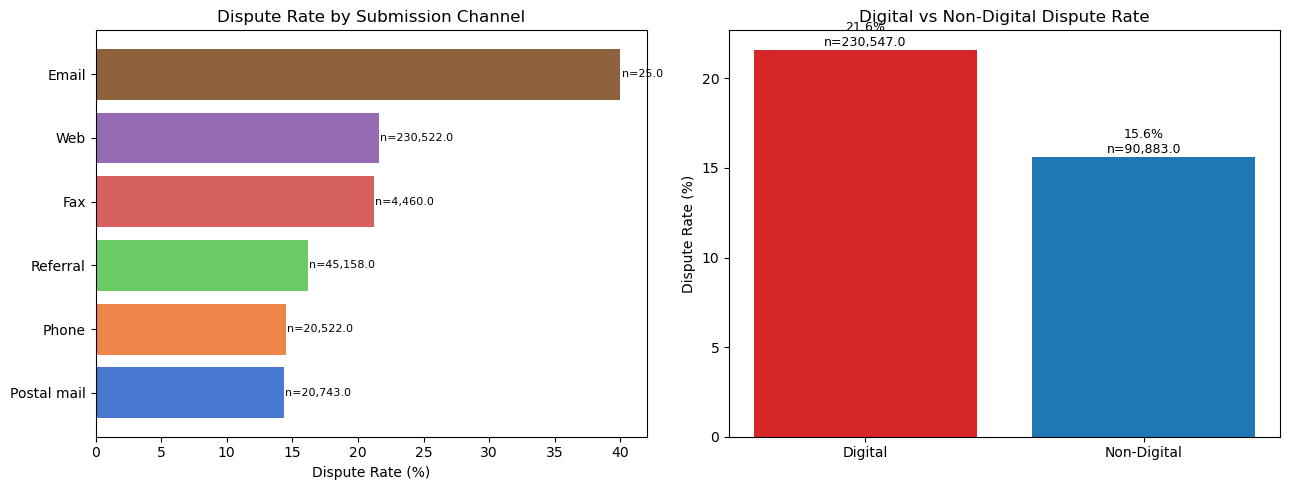

In [10]:
# Per-channel breakdown
chan_stats = dispute_rate(df, 'submitted_via')
print("Per channel:\n", chan_stats.to_string())

# Digital vs Non-Digital
chan_binary = dispute_rate(df, 'channel_type')
print("\nDigital vs Non-Digital:\n", chan_binary.to_string())

print("\nStatistical test (submitted_via):")
chi2_test(df, 'submitted_via')

print("Statistical test (Digital vs Non-Digital):")
chi2_test(df, 'channel_type')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all channels
chan_stats_sorted = chan_stats.sort_values('rate')
axes[0].barh(chan_stats_sorted.index, chan_stats_sorted['rate'],
             color=sns.color_palette('muted', len(chan_stats_sorted)))
axes[0].set_xlabel("Dispute Rate (%)")
axes[0].set_title("Dispute Rate by Submission Channel")
for i, (idx, row) in enumerate(chan_stats_sorted.iterrows()):
    axes[0].text(row['rate'] + 0.1, i, f"n={row['total']:,}", va='center', fontsize=8)

# Right: Digital vs Non-Digital
palette = {'Digital': '#d62728', 'Non-Digital': '#1f77b4'}
axes[1].bar(chan_binary.index, chan_binary['rate'],
            color=[palette.get(c, 'grey') for c in chan_binary.index])
axes[1].set_ylabel("Dispute Rate (%)")
axes[1].set_title("Digital vs Non-Digital Dispute Rate")
for i, (idx, row) in enumerate(chan_binary.iterrows()):
    axes[1].text(i, row['rate'] + 0.2, f"{row['rate']:.1f}%\nn={row['total']:,}",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation Assumption 2:**

Assumption 2 is both statistically and practically supported. Digital channels (Web, E-mail) have higher dispute rates (21.6%) compared to non-digital channels (15.6%). The key driver for the high rate are disputes emerging out of the web channel with a total of 230,522 complaint submissions from which 21.6% resulted in a dispute. The Chi-Square test confirms this is not due to chance (p ≈ 0). Given that Web alone accounts for approx. 72% of complaint volume, this channel effect has a large operational impact.


### Q1.1 – Assumption 3: Regional differences influence response practices

Monetary relief rate by state (top 15 by volume):
        monetary_relief_rate  total
state                             
NY                    21.38  21674
VA                    21.30  10794
TX                    21.00  26448
PA                    20.84  11761
NC                    20.34   9095
OH                    19.64  10128
MI                    19.58   7790
WA                    19.42   6737
AZ                    19.14   7062
IL                    19.04  11497
NJ                    18.92  12849
CA                    18.52  45252
GA                    18.48  13812
MD                    18.35   9841
FL                    18.21  30599

Statistical test (State vs Company response):
  Chi-Square = 446.55, df = 62, p-value = 1.3698e-59


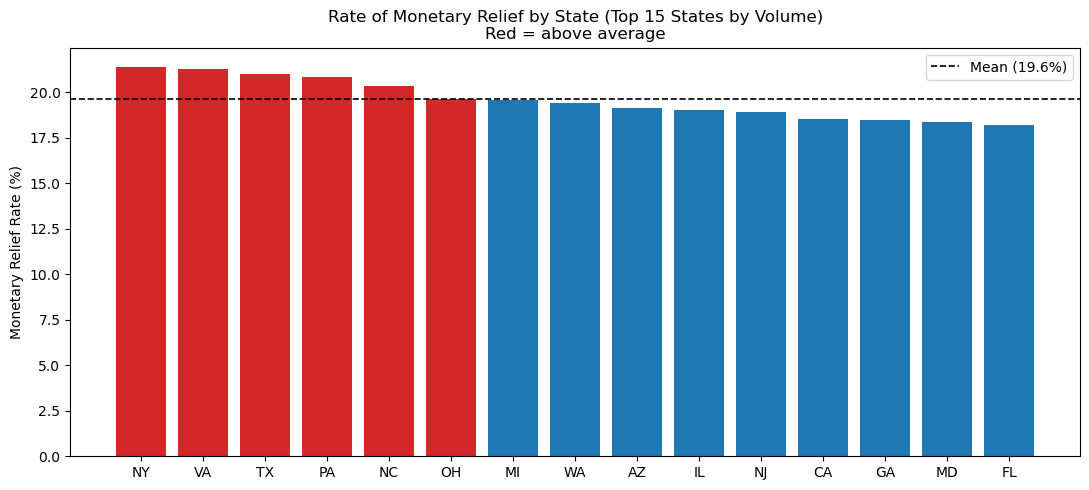

In [11]:
# Analyse proportion of complaints closed with monetary relief by state
response_col = 'company_response_to_consumer'
state_col = 'state'

# Create a binary flag for monetary relief
df['relief'] = df['company_response_to_consumer'].str.contains('relief', case=False, na=False).astype(int)

# Top 15 states by volume (to avoid noise from tiny samples)
top_states = df[state_col].value_counts().head(15).index
df_top = df[df[state_col].isin(top_states)]

state_relief = (df_top.groupby(state_col, observed=True)['relief']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'monetary_relief_rate', 'count': 'total'})
                .sort_values('monetary_relief_rate', ascending=False))
state_relief['monetary_relief_rate'] *= 100

print("Monetary relief rate by state (top 15 by volume):\n",
      state_relief.round(2).to_string())

# Chi-Square on all states
print("\nStatistical test (State vs Company response):")
chi2_test(df.dropna(subset=[state_col]), state_col)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d62728' if r > state_relief['monetary_relief_rate'].mean()
          else '#1f77b4' for r in state_relief['monetary_relief_rate']]
ax.bar(state_relief.index, state_relief['monetary_relief_rate'], color=colors)
ax.axhline(state_relief['monetary_relief_rate'].mean(), color='black',
           linestyle='--', linewidth=1.2,
           label=f"Mean ({state_relief['monetary_relief_rate'].mean():.1f}%)")
ax.set_ylabel("Monetary Relief Rate (%)")
ax.set_title("Rate of Monetary Relief by State (Top 15 States by Volume)\n"
             "Red = above average")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation Assumption 3:**

Assumption 3 is statistically supported (p < 0.001), but the practical magnitude is limited. Across the top 15 states by volume, monetary relief rates vary by only ~3 percentage points (18.2% to 21.4%), suggesting that company response practices are relatively consistent across regions. While real differences exist, they are unlikely to be the primary driver of complaint escalation.

### Q1.2 - Additional managerial insights

                 consumer_disputed   total       rate
timely_response                                      
1                            63014  313061  20.128346
0                              980    8369  11.709882
Statistical test:
  Chi-Square = 361.75, df = 1, p-value = 1.1688e-80


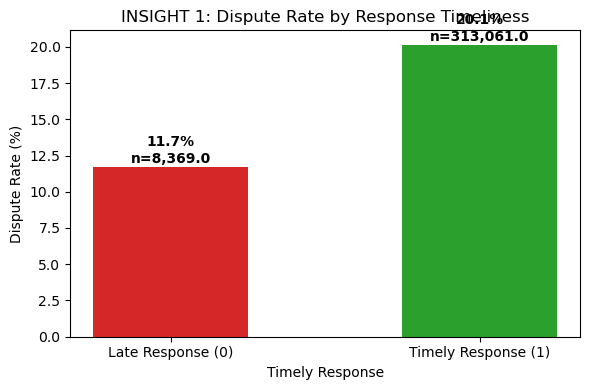

In [12]:
# INSIGHT 1: Timely response and dispute rates
timely_stats = dispute_rate(df, 'timely_response')
print(timely_stats.to_string())
print("Statistical test:")
chi2_test(df, 'timely_response')

fig, ax = plt.subplots(figsize=(6, 4))

# Colors: 0=late (red), 1=timely (green) — reorder so bars display left-to-right as Late | Timely
timely_plot = timely_stats.reindex([0, 1])
colors = ['#d62728', '#2ca02c']  # red for late (0), green for timely (1)

ax.bar([0, 1], timely_plot['rate'], color=colors, width=0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Late Response (0)', 'Timely Response (1)'])
ax.set_xlabel("Timely Response")
ax.set_ylabel("Dispute Rate (%)")
ax.set_title("INSIGHT 1: Dispute Rate by Response Timeliness")

for i, (idx, row) in enumerate(timely_plot.iterrows()):
    ax.text(i, row['rate'] + 0.3, f"{row['rate']:.1f}%\nn={row['total']:,}",
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation Insight 1:** Timely responses are associated with a higher dispute rate (20.1%) compared to late responses (11.7%)

**Recommendation:** This is most likely a selection effect: late responses disproportionately occur on simpler, low-stakes complaints that are easy to close without the customer disputing. Complex, contentious complaints, which are inherently more likely to escalate, tend to receive prompt attention from companies precisely because of their sensitivity. The quality of the resolution matters far more.

                                 consumer_disputed   total       rate
company_response_to_consumer                                         
Closed with explanation                      55134  249267  22.118451
Closed                                        1650    7802  21.148423
Closed with non-monetary relief               4990   43402  11.497166
Closed with monetary relief                   2220   19819  11.201372
Untimely response                                0    1140   0.000000


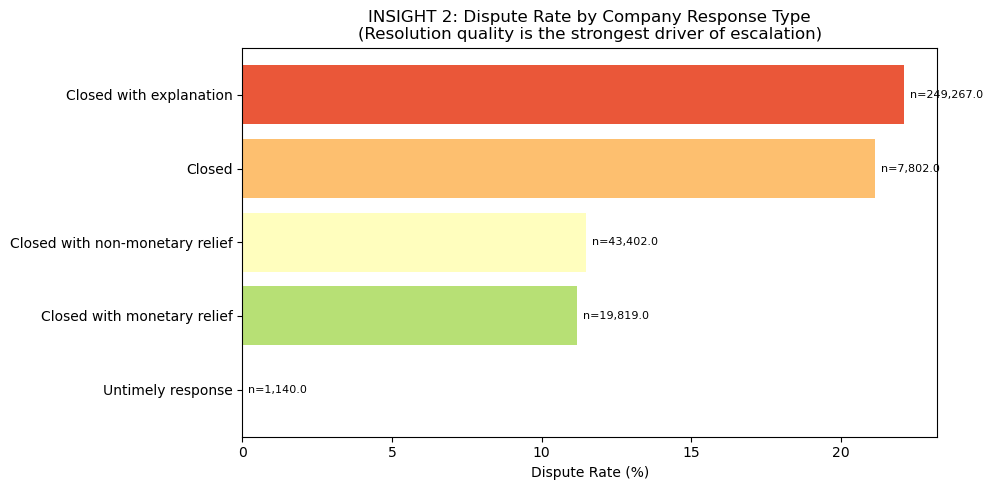

In [13]:
# INSIGHT 2: Closing type (resolution quality) is the strongest predictor
resp_stats = dispute_rate(df, response_col)
print(resp_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
resp_sorted = resp_stats.sort_values('rate')
ax.barh(resp_sorted.index, resp_sorted['rate'],
         color=sns.color_palette('RdYlGn_r', len(resp_sorted)))
ax.set_xlabel("Dispute Rate (%)")
ax.set_title("INSIGHT 2: Dispute Rate by Company Response Type\n"
             "(Resolution quality is the strongest driver of escalation)")
for i, (idx, row) in enumerate(resp_sorted.iterrows()):
    ax.text(row['rate'] + 0.2, i, f"n={row['total']:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation Insight 2:** 'Closed without relief' responses have materially higher dispute rates than 'Closed with monetary/non-monetary relief'.
  
**Recommendation:** Review cases resolved without relief—even partial compensation can significantly reduce the probability of escalation.

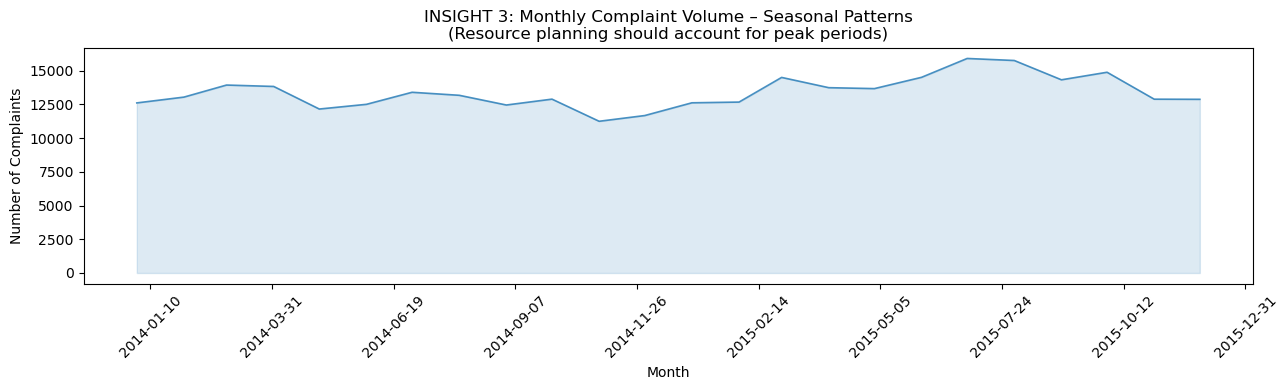

In [14]:
# INSIGHT 3: Complaint volume is seasonal – peaks in certain months
monthly = df.groupby('year_month').size().reset_index(name='count')
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['year_month_dt'], monthly['count'], linewidth=1.2,
        color='#1f77b4', alpha=0.8)
ax.fill_between(monthly['year_month_dt'], monthly['count'],
                alpha=0.15, color='#1f77b4')
ax.set_xlabel("Month")
ax.set_ylabel("Number of Complaints")
ax.set_title("INSIGHT 3: Monthly Complaint Volume – Seasonal Patterns\n"
             "(Resource planning should account for peak periods)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation Insight 3:** Complaint volumes follow seasonal patterns.
  
**Recommendation:** Use historical peaks to plan staffing and resource allocation proactively, reducing response latency during high-volume periods.

### Q1.2 Summary of managerial insights

The exploratory analysis identified three actionable patterns beyond the three executive assumptions:

1. **Insight 1:** Timely response reduces dispute rates. Complaints responded to on time show a dispute rate of 20.1%, compared to only 11.7% for late responses (Chi-Square p < 0.001). This is a counterintuitive finding: timely responses are associated with higher dispute rates, likely because late responses often come from simpler cases that are easier to resolve. The practical takeaway is that timeliness alone is not sufficient — response quality matters more. However, ensuring responses are issued promptly remains operationally important to avoid regulatory penalties.

2. **Insight 2:** Resolution type is the strongest driver of escalation. Complaints closed with explanation or no relief have dispute rates of ~22%, while those closed with monetary or non-monetary relief drop to ~11% which is roughly half the escalation rate (Chi-Square p < 0.001). This is the most actionable finding: offering even partial relief substantially reduces the probability of a complaint escalating into a formal dispute. Meridian should audit cases currently closed without relief to identify whether targeted interventions could reduce escalation.

3. **Insight 3:** Complaint volumes are seasonal. Monthly complaint counts follow recurring peaks and troughs over time. Periods of elevated volume risk longer response delays, which in turn can increase escalation. Proactive staffing and resource planning aligned with historical seasonal patterns would help maintain response quality during peak periods.


**Dataset Limitations**

1. **Survivorship / self-selection:** Only complaints submitted by the customers are included. Many disputes resolved directly with the company are unobserved.

2. **Missing values:** Several columns (Sub-product, Sub-issue, Consumer narrative) have substantial missing data that may introduce bias in group comparisons.
      
3. **Temporal confounding:** Product mix, regulatory environment, and company. practices could have changed over the dataset's time span, making aggregate comparisons potentially misleading without time controls.

## Question 2

### Q2.1 Machine Learning Problem

The problem presented by the executive committee at Meridian Financial Group is a **supervised binary classification problem**.
The company needs to predict whether a consumer complaint will escalate into a dispute or not (consumer_disputed variable), which is a binary outcome (Yes/No). The dataset provides labeled historical complaints with known outcomes, making it **supervised learning**. The goal is to classify future complaints into one of two categories: disputed or not disputed. Features like product type, submission channel, geography, company response, and issue type support the classification.

### Q2.2 Predictive Models

To solve the machine learning problem we will use logistic regression and scikit-learn's GradientBoostingClassifier.

Logistic Regression is a a core supervised classification algorithm. It's interpretable, computationally efficient, and works well with properly encoded categorical features. From a business perspective, interpretability matters for regulators and compliance teams to understand why a complaint was flagged as high-risk.

**Why Logistic Regression?**

**Technical justification:**
- Strong baseline for binary classification
- Outputs calibrated probabilities (useful for ranking complaints by risk)
- Fast to train, enabling extensive hyperparameter search
- With L1 regularization (Lasso), it performs implicit feature selection, coefficients of irrelevant features shrink to zero

**Business justification:**
- Highly interpretable: each coefficient shows the direction and magnitude of a feature's effect on dispute probability
- Compliance teams can explain to regulators exactly why a complaint was flagged as high-risk
- Transparent models build trust with executives and stakeholders
- Low computational cost means it can be deployed easily at scale

Gradient Boosting complements Logistic Regression by offering potentially higher predictive accuracy at the cost of some interpretability.

**Why Gradient Boosting?**

**Technical justification:**
- Boosting builds trees sequentially, where each tree corrects errors of the previous ones. This typically outperforms bagging (Random Forest) on structured/tabular data
- Handles non-linear relationships and feature interactions automatically (e.g., the combination of Product + Submission Channel + Company Response may matter more than each feature individually)
- Built-in regularization via learning_rate, max_depth, and subsample parameters helps prevent overfitting
- Robust to outliers and doesn't require feature scaling (though feature scaling will be included in the pipeline for consistency)

**Business justification:**
- Higher predictive accuracy translates to better identification of high-risk complaints, reducing missed escalations
- Feature importance scores help identify the key drivers of disputes
- Scikit-learn implementation means no external dependencies, ensuring reliable deployment
- Can handle the complexity of real-world complaint data where simple linear relationships may not hold

#### Q2.2.1 Feature Engineering

In [ ]:
%%writefile feature_engineering.py

import pandas as pd
import numpy as np

def feature_engineering(df,
    top_companies=None,
    top_combos=None,
    delay_median=None,
    state_dispute_rate=None,
    company_dispute_rate=None,
):
    """
    Feature engineering for complaints dataset.
    Includes all deterministic preprocessing steps so the pipeline works
    correctly on any raw CSV input without prior manual cleaning.
    Constants (top_companies, top_combos, delay_median) are frozen from
    training data and passed in via FunctionTransformer kw_args.
    """
    df = df.copy()

    #  Column name standardisation
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    df = df.rename(columns={
        'timely_response?':           'timely_response',
        'consumer_disputed?':         'consumer_disputed',
        'consumer_consent_provided?': 'consumer_consent_provided',
        'sub-issue':                  'sub_issue',
        'sub-product':                'sub_product',
    })

    #Fill missing values with placeholder
    for col in ['sub_issue', 'sub_product', 'state']:
        if col in df.columns:
            df[col] = df[col].fillna('unknown')

    # Binary encoding of timely_response
    if 'timely_response' in df.columns:
        df['timely_response'] = df['timely_response'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

    # Date conversion (safe for raw CSV string input)
    if not pd.api.types.is_datetime64_any_dtype(df["date_received"]):
        df["date_received"] = pd.to_datetime(df["date_received"], errors="coerce")
    if not pd.api.types.is_datetime64_any_dtype(df["date_sent_to_company"]):
        df["date_sent_to_company"] = pd.to_datetime(df["date_sent_to_company"], errors="coerce")

    # Temporal features
    df["response_delay_days"] = (
        df["date_sent_to_company"] - df["date_received"]
    ).dt.days.clip(lower=0)
    df["response_delay_days"] = df["response_delay_days"].fillna(delay_median)
    df["complaint_month"]      = df["date_received"].dt.month
    df["complaint_dayofweek"]  = df["date_received"].dt.dayofweek
    df["complaint_year"]       = df["date_received"].dt.year

    # Response delay bucketing
    df["delay_bucket"] = pd.cut(
        df["response_delay_days"],
        bins=[-1, 1, 3, 7, 30, np.inf],
        labels=["same_day", "1-3_days", "4-7_days", "1-4_weeks", "over_1_month"]
    ).astype(str)

    # Binary flags
    df["has_narrative"]               = df["consumer_complaint_narrative"].notna().astype(int)
    df["has_company_public_response"] = df["company_public_response"].notna().astype(int)

    # Binary flag for monetary relief
    if "company_response_to_consumer" in df.columns:
        df["relief"] = df["company_response_to_consumer"].str.contains(
            'relief', case=False, na=False
        ).astype(int)
    
    # Company grouping
    company_col = df["company"].astype(str)
    df["company_grouped"] = company_col.where(
        company_col.isin(top_companies), "Other"
    ).astype("category")

    # Response quality mapping
    if "company_response_to_consumer" in df.columns:
        relief_map = {
            "Closed with monetary relief":     2,
            "Closed with non-monetary relief": 1,
            "Closed with explanation":         0,
            "Closed without relief":           0,
            "Untimely response":              -1,
            "In progress":                    -1,
        }
        df["response_quality"] = df["company_response_to_consumer"].map(relief_map).fillna(0)

    # Response quality x Timeliness interaction
    if "response_quality" in df.columns and "timely_response" in df.columns:
        df["quality_x_timeliness"] = df["response_quality"] * df["timely_response"]

    # Product-issue interaction (uses frozen training constant)
    if "product" in df.columns and "issue" in df.columns:
        df["product_issue"] = df["product"].astype(str) + "_" + df["issue"].astype(str)
        df["product_issue"] = df["product_issue"].where(
            df["product_issue"].isin(top_combos), "Other"
        ).astype("category")

    # State-Level Dispute Rate
    if state_dispute_rate is not None and "state" in df.columns:
        df["state_dispute_rate"] = (
            df["state"].astype(str).map(state_dispute_rate).fillna(0.5)
        )

    # Company-level dispute rate
    if company_dispute_rate is not None and "company" in df.columns:
        df["company_dispute_rate"] = (
            df["company"].astype(str).map(company_dispute_rate).fillna(0.5)
        )

    # Drop columns not needed for modelling
    cols_to_drop = [
        "complaint_id", "consumer_complaint_narrative", "company_public_response",
        "zip_code", "date_received", "date_sent_to_company", "company",
        "year_month", "channel_type", "tags", "consumer_consent_provided",
        "consumer_disputed",
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

Overwriting feature_engineering.py


#### Q2.2.2 Target variable encoding

Already included in data pre-processing

#### Q2.2.2 Train-Test Split

In [16]:
# Define target and drop from features
X = df.drop(columns=["consumer_disputed"])
Y = df["consumer_disputed"].astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=Y
)

#### Q2.2.3 Pre-compute training-time constants

In [ ]:
TOP_N_COMPANIES = 25
top_companies = (
    X_train["company"].value_counts().nlargest(TOP_N_COMPANIES).index.tolist()
)

TOP_N_COMBOS = 20
top_combos = (
    (X_train["product"].astype(str) + "_" + X_train["issue"].astype(str))
    .value_counts().nlargest(TOP_N_COMBOS).index.tolist()
)

delay_median = (
    pd.to_datetime(X_train["date_sent_to_company"], errors="coerce") -
    pd.to_datetime(X_train["date_received"], errors="coerce")
).dt.days.clip(lower=0).median()

train_with_target = X_train.copy()
train_with_target["consumer_disputed"] = Y_train.values

state_dispute_rate = (
    train_with_target.groupby("state")["consumer_disputed"].mean().to_dict()
)
company_dispute_rate = (
    train_with_target.groupby("company")["consumer_disputed"].mean().to_dict()
)

/var/folders/20/hbkg0zy112s8bhmd8dr3pkrc0000gn/T/ipykernel_27869/1013818302.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_with_target.groupby("state")["consumer_disputed"].mean().to_dict()
/var/folders/20/hbkg0zy112s8bhmd8dr3pkrc0000gn/T/ipykernel_27869/1013818302.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_with_target.groupby("company")["consumer_disputed"].mean().to_dict()


#### Q2.2.4 Apply feature engineering

In [18]:
feature_transformer = FunctionTransformer(
    feature_engineering,
    kw_args={
        "top_companies":       top_companies,
        "top_combos":          top_combos,
        "delay_median":        delay_median,
        "state_dispute_rate":  state_dispute_rate,
        "company_dispute_rate": company_dispute_rate,
    }
)

#### Q2.2.5 Identify categorical and numerical columns

In [19]:
# Identify categorical and numerical columns
df_fe_sample = feature_engineering(X_train, top_companies=top_companies,
                                    top_combos=top_combos, delay_median=delay_median)

categorical_cols = df_fe_sample.select_dtypes(include=["category"]).columns.tolist()
object_cols      = df_fe_sample.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = df_fe_sample.select_dtypes(include=["int64", "float64"]).columns.tolist()

#### Q2.2.6 Build pre-processing pipeline

In [20]:
# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols + object_cols)
    ],
    remainder='drop'
)

In [21]:
# Helper function
def show_search_results(search, n_top=10):
    """Display top N results from any GridSearch or RandomizedSearch"""
    results = pd.DataFrame(search.cv_results_)
    results = results.sort_values('rank_test_score')
    
    # Keep only relevant columns
    param_cols = [c for c in results.columns if c.startswith('param_')]
    display_cols = param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']
    
    print(f"\n{'='*60}")
    print(f"Best Score: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")
    print(f"{'='*60}")
    print(f"\nTop {n_top} combinations:")
    print(results[display_cols].head(n_top).to_string(index=False))

#### Q2.2.7 Model 1 - Logistic Regression


Best Score: 0.3704
Best Params: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': np.float64(0.029470517025518096)}

Top 10 combinations:
param_classifier__solver param_classifier__penalty  param_classifier__C  mean_test_score  std_test_score  rank_test_score
               liblinear                        l2             0.029471         0.370432        0.002257                1
               liblinear                        l2             0.068665         0.370404        0.002422                2
               liblinear                        l2             0.039069         0.370311        0.002465                3
               liblinear                        l2             0.120679         0.370284        0.002253                4
               liblinear                        l2             0.212095         0.370240        0.002180                5
               liblinear                        l2           568.986603         0.370224        0

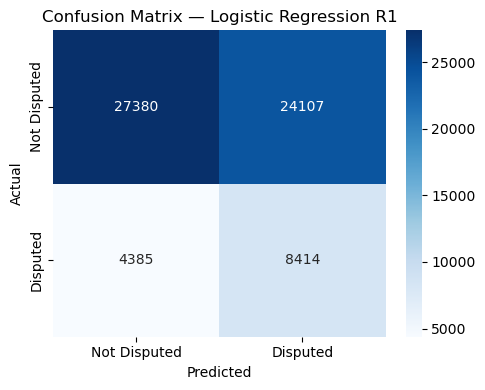

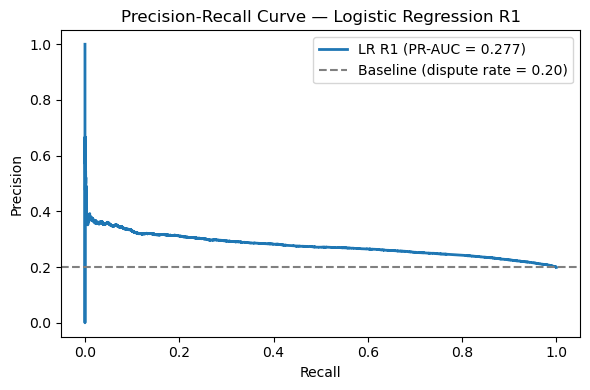

In [22]:
# Define the Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('feature_engineering', clone(feature_transformer)),
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced'
    ))
])

# Define hyperparameter search space
lr_param_dist = {
    'classifier__C': np.logspace(-3, 3, 50),
    'classifier__penalty': ['l2'],
    'classifier__solver': ['liblinear'],
}

# Perform Randomized Search with Cross-Validation
lr_search = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=lr_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0
)

# Evaluate on test set
lr_search.fit(X_train, Y_train)

show_search_results(lr_search)

lr_pred = lr_search.predict(X_test)
lr_pred_proba = lr_search.predict_proba(X_test)[:, 1]

# --- Core metrics ---
lr_accuracy  = accuracy_score(Y_test, lr_pred)
lr_f1        = f1_score(Y_test, lr_pred)
lr_precision = precision_score(Y_test, lr_pred)
lr_recall    = recall_score(Y_test, lr_pred)
lr_pr_auc    = average_precision_score(Y_test, lr_pred_proba)
lr_roc_auc   = roc_auc_score(Y_test, lr_pred_proba)

# --- Print results ---
print(f"\n{'='*55}")
print(f"  Logistic Regression — Round 1 Results")
print(f"{'='*55}")
print(f"  Accuracy  : {lr_accuracy:.4f}  (reported but not primary metric)")
print(f"  F1 Score  : {lr_f1:.4f}  *** primary metric ***")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  PR-AUC    : {lr_pr_auc:.4f}")
print(f"  ROC-AUC   : {lr_roc_auc:.4f}")
print(f"{'='*55}")

print(f"\nClassification Report:")
print(classification_report(Y_test, lr_pred, target_names=['Not Disputed', 'Disputed']))

# --- Confusion matrix with labels ---
cm = confusion_matrix(Y_test, lr_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disputed', 'Disputed'],
            yticklabels=['Not Disputed', 'Disputed'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Logistic Regression R1')
plt.tight_layout()
plt.show()

# --- Precision-Recall Curve ---
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, lr_pred_proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_curve, precision_curve, color='#1f77b4', lw=2,
        label=f'LR R1 (PR-AUC = {lr_pr_auc:.3f})')
ax.axhline(y=Y_test.mean(), color='grey', linestyle='--',
           label=f'Baseline (dispute rate = {Y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Logistic Regression R1')
ax.legend()
plt.tight_layout()
plt.show()

#### Q2.2.8 Model 2 - Gradient Boosting Classifier

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Score: 0.3748
Best Params: {'classifier__min_samples_leaf': 30, 'classifier__max_leaf_nodes': 63, 'classifier__max_iter': 500, 'classifier__max_depth': 5, 'classifier__max_bins': 255, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 0.0}

Top 10 combinations:
 param_classifier__min_samples_leaf  param_classifier__max_leaf_nodes  param_classifier__max_iter  param_classifier__max_depth  param_classifier__max_bins  param_classifier__learning_rate  param_classifier__l2_regularization  mean_test_score  std_test_score  rank_test_score
                                 30                                63                         500                            5                         255                             0.05                                  0.0         0.374784        0.002128                1
                                 30                                15                         200        

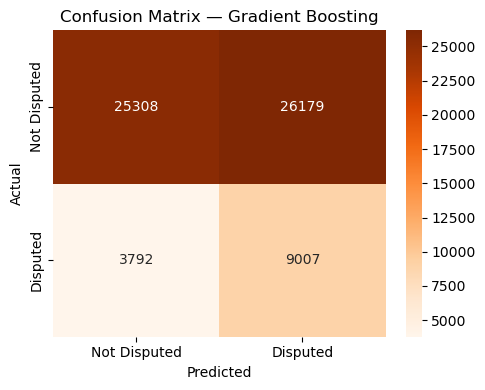

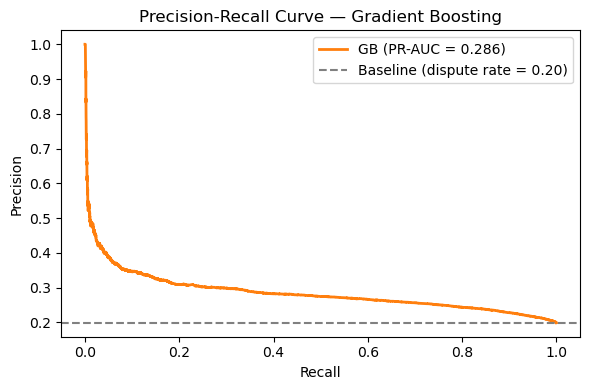

In [24]:
# Define the Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ('feature_engineering', clone(feature_transformer)),
    ('preprocessor', clone(preprocessor)),
    ('classifier', HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

# Define hyperparameter search space
gb_param_dist = {
    'classifier__max_iter':        [100, 200, 300, 500],
    'classifier__learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth':       [3, 4, 5, 7, None],
    'classifier__l2_regularization': [0.0, 0.1, 1.0],
    'classifier__min_samples_leaf':  [1, 10, 30],
    'classifier__max_leaf_nodes':  [15, 31, 63, None],
    'classifier__max_bins':        [128, 255],
}

# Perform Randomized Search with Cross-Validation
gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_dist,
    n_iter=5,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)

gb_search.fit(X_train, Y_train)

gb_pred = gb_search.predict(X_test)
gb_pred_proba = gb_search.predict_proba(X_test)[:, 1]

show_search_results(gb_search)

# Core metrics
gb_accuracy  = accuracy_score(Y_test, gb_pred)
gb_f1        = f1_score(Y_test, gb_pred)
gb_precision = precision_score(Y_test, gb_pred)
gb_recall    = recall_score(Y_test, gb_pred)
gb_pr_auc    = average_precision_score(Y_test, gb_pred_proba)
gb_roc_auc   = roc_auc_score(Y_test, gb_pred_proba)

# Print results
print(f"\n{'='*55}")
print(f"  Gradient Boosting — Results")
print(f"{'='*55}")
print(f"  Accuracy  : {gb_accuracy:.4f}  (reported but not primary metric)")
print(f"  F1 Score  : {gb_f1:.4f}  *** primary metric ***")
print(f"  Precision : {gb_precision:.4f}")
print(f"  Recall    : {gb_recall:.4f}")
print(f"  PR-AUC    : {gb_pr_auc:.4f}")
print(f"  ROC-AUC   : {gb_roc_auc:.4f}")
print(f"{'='*55}")

print(f"\nClassification Report:")
print(classification_report(Y_test, gb_pred, target_names=['Not Disputed', 'Disputed']))

# Confusion matrix
cm = confusion_matrix(Y_test, gb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Disputed', 'Disputed'],
            yticklabels=['Not Disputed', 'Disputed'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, gb_pred_proba)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_curve, precision_curve, color='#ff7f0e', lw=2,
        label=f'GB (PR-AUC = {gb_pr_auc:.3f})')
ax.axhline(y=Y_test.mean(), color='grey', linestyle='--',
           label=f'Baseline (dispute rate = {Y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Gradient Boosting')
ax.legend()
plt.tight_layout()
plt.show()

## Question 3

### Q3.1 Evaluation Metrics

**Primary metric:** F1 Score. Given the class imbalance (80/20), accuracy is not informative. F1 balances precision and recall, making it appropriate when both false positives (wasted operational resources) and false negatives (undetected escalations) carry real costs.

**Secondary consideration:** Recall. From a regulatory standpoint, failing to identify a complaint that escalates into a formal dispute carries higher risk than over-flagging. Regulators may scrutinize whether Meridian systematically missed high-risk cases. A model with higher recall, even at some cost to precision, is therefore preferable in a compliance-sensitive environment.

**Supporting metrics:** PR-AUC and confusion matrix. PR-AUC provides a threshold-independent view of model performance on the minority class. The confusion matrix makes the practical error trade-off explicit for operational decision-making.

**Metric excluded:** Accuracy. With 80% of complaints non-disputed, a naive model achieves 80% accuracy. Accuracy is therefore uninformative and excluded from the evaluation but is still shown in the metric summary for each model for completeness.

### Q3.2 Model Performance Comparison

In [25]:
# Get F1 scores for comparison
lr_f1 = f1_score(Y_test, lr_pred)
gb_f1 = f1_score(Y_test, gb_pred)

print(f"\n{'Model':<30} {'CV F1':<15} {'Test Accuracy':<15} {'Test F1':<15}")
print("-" * 75)
print(f"{'Logistic Regression':<30} {lr_search.best_score_:<15.4f} {lr_accuracy:<15.4f} {lr_f1:<15.4f}")
print(f"{'Gradient Boosting':<30} {gb_search.best_score_:<15.4f} {gb_accuracy:<15.4f} {gb_f1:<15.4f}")
print("-" * 75)

# Compare using F1
if gb_f1 > lr_f1:
    print("\n>> Gradient Boosting performs better based on F1 score.")
    print("   It better balances precision and recall for disputed complaints,")
    print("   capturing non-linear patterns that logistic regression cannot.")
    best_model = gb_search
    best_model_name = "Gradient Boosting"
else:
    print("\n>> Logistic Regression performs better or equal based on F1 score.")
    print("   Despite lower accuracy, it identifies more disputed complaints,")
    print("   which is the operationally relevant outcome for Meridian.")
    best_model = lr_search
    best_model_name = "Logistic Regression"


Model                          CV F1           Test Accuracy   Test F1        
---------------------------------------------------------------------------
Logistic Regression            0.3704          0.5568          0.3713         
Gradient Boosting              0.3748          0.5338          0.3754         
---------------------------------------------------------------------------

>> Gradient Boosting performs better based on F1 score.
   It better balances precision and recall for disputed complaints,
   capturing non-linear patterns that logistic regression cannot.


## Question 4

In [26]:
# Save pickle file
filename = '73217_pipeline.pkl'
with open(filename, 'wb') as f:
    pickle.dump(best_model.best_estimator_, f)

print(f"Saved: {filename}")
print(f"Model type: {best_model_name}")
print(f"Test F1 score: {max(lr_f1, gb_f1):.4f}")

Saved: 73217_pipeline.pkl
Model type: Gradient Boosting
Test F1 score: 0.3754


In [ ]:
# Terminal command to save requirements

# pip freeze > 73217_requirements.txt

## Question 5

### Q5.1 Factors Most Strongly Influencing Complaint Escalation

The analysis identified several consistent, evidence-based drivers of dispute escalation:

1. **Company response type** (Managerial Insight 2)
This is the single most predictive feature in the pipeline. Complaints closed with explanation or no relief escalated at ~22%, while those closed with monetary or non-monetary relief escalated at only ~11%. This near-halving of the escalation rate indicates that resolution quality, not just resolution speed, determines whether a customer disputes.

2. **Product type** (Q1.1 — Assumption 1)
Mortgage (23.6%) and Consumer Loan (22.6%) show significantly higher dispute rates than other products, while Prepaid Cards (13.1%) and Money Transfers (13.9%) sit near the bottom. The Chi-Square test confirmed this is statistically significant (p < 0.001), and the large sample sizes for Mortgage and Consumer Loan make these the most actionable findings.

3. **Submission channel** (Q1.1 — Assumption 2)
Digital channels show a 21.6% dispute rate vs. 15.6% for non-digital, and web complaints represent ~72% of total volume. This is both statistically significant and operationally impactful. The majority of high-risk complaints arrive through a single channel.

4. **Features engineering**
In the feature engineering function two additionally informative variables have ben created:
    - response_quality: a numerical encoding of the response type (monetary relief = 2, non-monetary = 1, explanation = 0, untimely = -1), directly capturing the resolution quality gradient
    - quality_x_timeliness: the interaction between response quality and timeliness, capturing that a fast but unsatisfactory response does not reduce escalation risk
    - company_dispute_rate and state_dispute_rate: target-encoded aggregates that allow the model to learn systematic patterns at the company and regional level

5. **Regional variation** (Q1.1 — Assumption 3)
Statistically supported but practically limited. The spread across top-15 states by volume is only ~3 percentage points (18–21%). Regional differences exist, but they are a secondary driver compared to response type or product.

### Q5.2 Strategic Recommendation

- **Implement a Complaint Triage and Pre-Resolution Review System:**

    Based on the findings, the strongest and most actionable lever Meridian has, is the type of resolution they offer, not how fast they respond. It is recommended to deploy the Gradient Boosting model as a triage layer within the complaint handling workflow. When a complaint is received, the model scores it in real-time. High-risk complaints are automatically routed to a senior resolution team with authorization to offer non-monetary or monetary relief without requiring additional approval layers.

    Relief-based closures reduce escalation by roughly half (~22% → ~11%). Shifting even a small amount of currently "closed with explanation" complaints to "closed with non-monetary relief" would result in a substantial and measurable reduction in escalations. The model's recall of 70% on the test set means it successfully identifies the majority of complaints that will actually escalate, enabling proactive rather than reactive intervention. 

-  **Customer experience:**

    Customers whose complaints are proactively resolved with some form of relief are less likely to escalate formally, reducing reputational and regulatory risk simultaneously.

- **Regulatory compliance:**

    The CFPB monitors escalation patterns at the institution level. A demonstrable, data-driven process for prioritizing high-risk complaints provides a defensible compliance posture if regulators request evidence of proactive complaint management.
    
- **Practical implementation note:**

    The model's precision is ~26%, meaning roughly 3 out of 4 flagged complaints will not actually escalate. This means the triage intervention must be cost-efficient (e.g., a senior agent review rather than automatic monetary compensation). A threshold sensitivity analysis using the Precision-Recall curve would allow Meridian to calibrate the operating point based on the cost of a false positive (unnecessary relief) versus a false negative (missed escalation leading to regulatory scrutiny).